In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Student_Performance.csv')

In [5]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [8]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [9]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(127)

In [14]:
df.duplicated().value_counts()

False    9873
True      127
Name: count, dtype: int64

In [15]:
df[df.duplicated()]

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
915,9,52,No,5,9,48.0
1477,7,61,Yes,6,8,54.0
1601,5,99,No,7,5,89.0
1786,2,62,Yes,9,4,40.0
2026,5,87,Yes,6,7,74.0
...,...,...,...,...,...,...
9644,4,91,Yes,4,3,71.0
9940,8,95,No,5,2,90.0
9954,6,97,No,8,7,92.0
9966,1,41,No,7,3,12.0


In [18]:
df = df.drop_duplicates()

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [23]:
df['Extracurricular Activities'].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

<Axes: xlabel='Extracurricular Activities'>

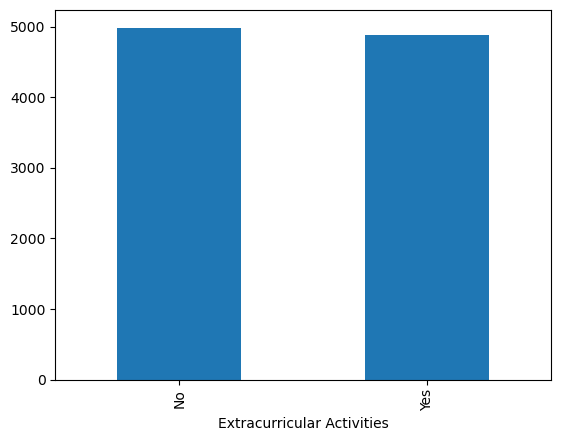

In [22]:
df['Extracurricular Activities'].value_counts().plot(kind='bar')

<Axes: xlabel='Sleep Hours', ylabel='Count'>

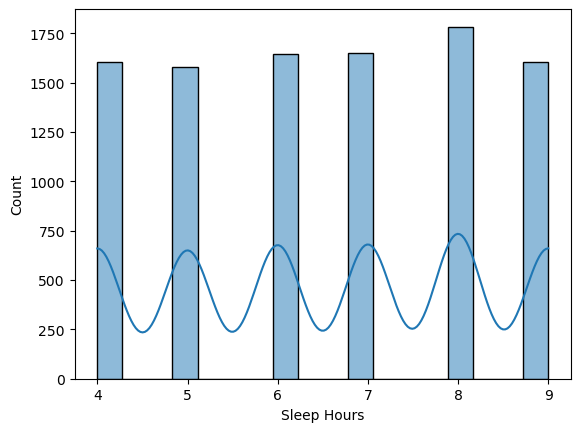

In [24]:
sns.histplot(df['Sleep Hours'],kde=True)

<Axes: xlabel='Hours Studied', ylabel='Count'>

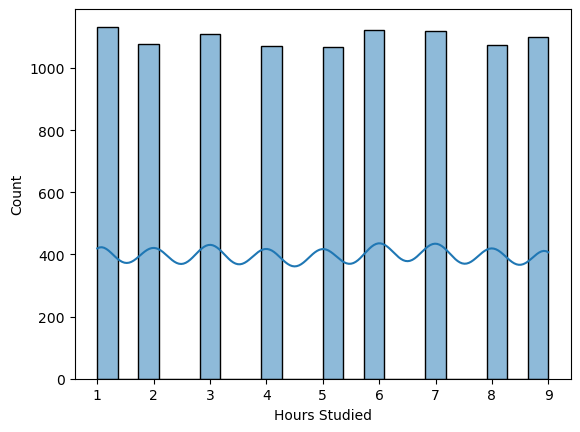

In [25]:
sns.histplot(df['Hours Studied'],kde=True)

<Axes: xlabel='Performance Index', ylabel='Count'>

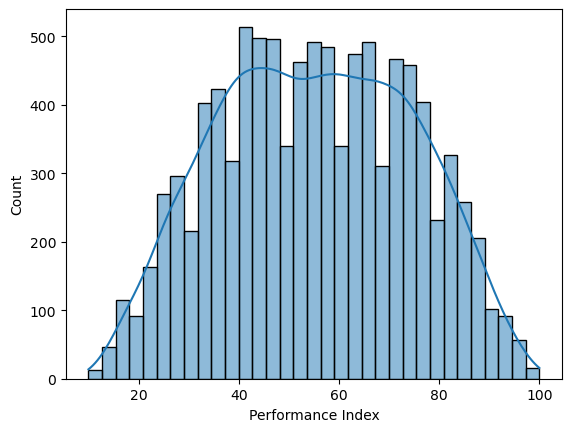

In [26]:
sns.histplot(df['Performance Index'],kde=True)

<Axes: >

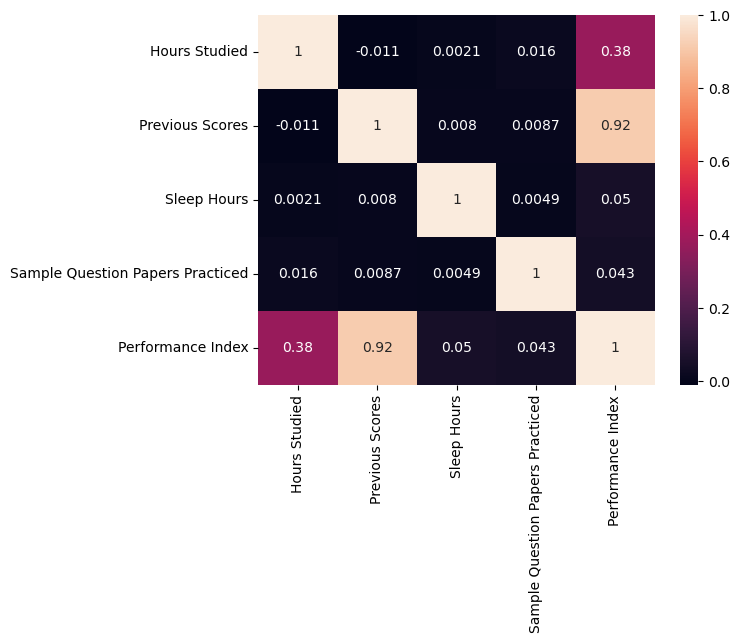

In [30]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [34]:
df['Extracurricular Activities'].value_counts()

Extracurricular Activities
No     4986
Yes    4887
Name: count, dtype: int64

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Extracurricular Activities'] = le.fit_transform(
    df['Extracurricular Activities'])

In [38]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [39]:
from sklearn.preprocessing import StandardScaler
num_cols=['Hours Studied','Previous Scores','Sleep Hours','Sample Question Papers Practiced','Performance Index']
scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,0.775566,1.706168,1,1.454025,-1.249715,1.862979
1,-0.383205,0.724912,0,-1.491315,-0.900925,0.509348
2,1.161822,-1.064438,1,0.275889,-0.900925,-0.531907
3,0.003052,-1.006717,1,-0.902247,-0.900925,-1.000471
4,0.775566,0.320865,0,0.864957,0.145444,0.561411


In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X=df.drop('Performance Index',axis=1)
y=df['Performance Index']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [45]:
y_pred=model.predict(X_test)

In [46]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]   # number of rows (samples)
p = X_test.shape[1]   # number of columns (features)

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("R2:", r2)
print("Adjusted R2:", adjusted_r2)

R2: 0.9884301209927054
Adjusted R2: 0.9884007409038094
